<a href="https://colab.research.google.com/github/adyashapadhy25/security_log_analyzer/blob/main/Cybersecurity_Log_Analyzer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import random
from datetime import datetime, timedelta

random.seed(42)

# Sample IPs, usernames, endpoints
normal_ips = ['192.168.1.10', '192.168.1.11', '192.168.1.12', '10.0.0.5', '10.0.0.6']
suspicious_ips = ['192.168.1.45', '10.20.5.18', '172.16.2.4']
usernames = ['admin', 'john_doe', 'jane_smith', 'guest', 'finance_user', 'hr_manager']
endpoints = ['/login', '/dashboard', '/admin_panel', '/reports', '/user_data']

logs = []
start_time = datetime(2026, 9, 1, 0, 0, 0)


for i in range(300):
    log_time = start_time + timedelta(minutes=random.randint(0, 10000))
    logs.append({
        'timestamp': log_time,
        'ip': random.choice(normal_ips),
        'username': random.choice(usernames),
        'status': random.choices(['success', 'fail'], weights=[85, 15])[0],
        'endpoint': random.choice(endpoints)
    })


brute_time = start_time + timedelta(days=2, hours=10)
for i in range(14):
    logs.append({
        'timestamp': brute_time + timedelta(minutes=i*2),
        'ip': '192.168.1.45',
        'username': 'admin',
        'status': 'fail',
        'endpoint': '/login'
    })


scan_time = start_time + timedelta(days=3, hours=15)
for i in range(23):
    logs.append({
        'timestamp': scan_time + timedelta(minutes=i*3),
        'ip': '10.20.5.18',
        'username': f'user_{i}',
        'status': 'fail',
        'endpoint': '/login'
    })


night_time = start_time + timedelta(days=4, hours=2)
for i in range(6):
    logs.append({
        'timestamp': night_time + timedelta(minutes=i*10),
        'ip': '172.16.2.4',
        'username': 'finance_user',
        'status': 'success',
        'endpoint': '/reports'
    })

df = pd.DataFrame(logs)
df = df.sort_values('timestamp').reset_index(drop=True)
df.head(10)

,timestamp,ip,username,status,endpoint
0,2026-09-01 00:06:00,192.168.1.12,jane_smith,success,/user_data
1,2026-09-01 00:43:00,10.0.0.5,guest,success,/reports
2,2026-09-01 01:30:00,192.168.1.10,guest,success,/user_data
3,2026-09-01 03:48:00,192.168.1.12,finance_user,success,/admin_panel
4,2026-09-01 04:01:00,192.168.1.10,john_doe,success,/reports
5,2026-09-01 05:19:00,192.168.1.10,jane_smith,fail,/admin_panel
6,2026-09-01 05:49:00,192.168.1.10,jane_smith,success,/dashboard
7,2026-09-01 07:02:00,192.168.1.11,admin,success,/dashboard
8,2026-09-01 07:10:00,10.0.0.6,hr_manager,success,/admin_panel
9,2026-09-01 07:21:00,10.0.0.5,finance_user,success,/login


In [ ]:

failed_logs = df[df['status'] == 'fail']

def max_fails_in_window(g, minutes=30):
    t = g['timestamp'].sort_values().reset_index(drop=True)
    best, j = 0, 0
    for i in range(len(t)):
        while t[i] - t[j] > pd.Timedelta(minutes=minutes):
            j += 1
        best = max(best, i - j + 1)
    return best

burst = failed_logs.groupby('ip').apply(max_fails_in_window).reset_index(name='fail_count')
brute_force_ips = burst[burst['fail_count'] >= 10]

print("Brute-force Suspects (10+ fails within 30 minutes):")
brute_force_ips

Brute-force Suspects (10+ fails within 30 minutes):


/tmp/ipykernel_809/2549089128.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  burst = failed_logs.groupby('ip').apply(max_fails_in_window).reset_index(name='fail_count')


,ip,fail_count
2,10.20.5.18,11
6,192.168.1.45,14


In [ ]:
username_fail_counts = failed_logs.groupby('username').size().reset_index(name='fail_count')
targeted_accounts = username_fail_counts[username_fail_counts['fail_count'] >= 5]

print("Targeted Accounts:")
targeted_accounts

Targeted Accounts:


,username,fail_count
0,admin,22
1,finance_user,8
2,guest,13
3,hr_manager,6
4,jane_smith,7
5,john_doe,10


In [ ]:

ip_scanning = failed_logs.groupby('ip')['username'].nunique().reset_index(name='unique_accounts_tried')


scanning_ips = ip_scanning[ip_scanning['unique_accounts_tried'] >= 10]

print("IP Scanning Suspects:")
scanning_ips

IP Scanning Suspects:


,ip,unique_accounts_tried
2,10.20.5.18,23


In [ ]:

df['hour'] = df['timestamp'].dt.hour


unusual_hour_logs = df[(df['hour'] >= 2) & (df['hour'] < 4)]

print("Unusual Hour Activity (2 AM - 4 AM):")
unusual_hour_logs[['timestamp', 'ip', 'username', 'status', 'endpoint']]

Unusual Hour Activity (2 AM - 4 AM):


,timestamp,ip,username,status,endpoint
3,2026-09-01 03:48:00,192.168.1.12,finance_user,success,/admin_panel
42,2026-09-02 02:52:00,192.168.1.10,guest,success,/login
43,2026-09-02 03:02:00,10.0.0.5,finance_user,success,/admin_panel
44,2026-09-02 03:04:00,192.168.1.10,hr_manager,success,/user_data
45,2026-09-02 03:05:00,192.168.1.11,hr_manager,success,/login
46,2026-09-02 03:13:00,10.0.0.6,guest,success,/dashboard
47,2026-09-02 03:49:00,192.168.1.12,hr_manager,success,/login
48,2026-09-02 03:54:00,192.168.1.10,guest,success,/admin_panel
96,2026-09-03 03:30:00,192.168.1.11,finance_user,success,/reports
97,2026-09-03 03:54:00,192.168.1.12,admin,success,/login


In [ ]:

restricted_endpoints = ['/admin_panel', '/user_data']


restricted_logs = df[df['endpoint'].isin(restricted_endpoints)]


repeated_access = restricted_logs.groupby(['ip', 'endpoint']).size().reset_index(name='access_count')


suspicious_repeated_access = repeated_access[repeated_access['access_count'] >= 15]

print("Repeated Restricted Access Suspects:")
suspicious_repeated_access

Repeated Restricted Access Suspects:


,ip,endpoint,access_count
1,10.0.0.5,/user_data,19
3,10.0.0.6,/user_data,15


In [ ]:
print("=" * 50)
print("SECURITY ALERTS")
print("=" * 50)
print()

# Rule 1: Brute-force
for _, row in brute_force_ips.iterrows():
    print(f"[HIGH] {row['ip']}")
    print(f"{row['fail_count']} failed login attempts")
    print("Possible brute-force activity")
    print()

# Rule 2: Account Targeting
for _, row in targeted_accounts.iterrows():
    print(f"[MEDIUM] Account: {row['username']}")
    print(f"{row['fail_count']} failed login attempts on this account")
    print("Possible targeted attack")
    print()

# Rule 3: IP Scanning
for _, row in scanning_ips.iterrows():
    print(f"[MEDIUM] {row['ip']}")
    print(f"Accessed {row['unique_accounts_tried']} different accounts")
    print("Possible account enumeration")
    print()

# Rule 4: Unusual Hours
unusual_ips = unusual_hour_logs['ip'].unique()
for ip in unusual_ips:
    times = unusual_hour_logs[unusual_hour_logs['ip'] == ip]['timestamp']
    print(f"[LOW] {ip}")
   print(f"{len(times)} logins between 2 AM and 4 AM")
    print()

# Rule 5: Repeated Restricted Access
for _, row in suspicious_repeated_access.iterrows():
    print(f"[LOW] {row['ip']}")
    print(f"Accessed {row['endpoint']} {row['access_count']} times")
    print("Repeated restricted endpoint access")
    print()

print("=" * 50)
print(f"Total Alerts Generated: {len(brute_force_ips) + len(scanning_ips) + len(unusual_ips) + len(targeted_accounts) + len(suspicious_repeated_access)}")
print("=" * 50)

SECURITY ALERTS

[HIGH] 10.0.0.5
14 failed login attempts
Possible brute-force activity

[HIGH] 10.0.0.6
10 failed login attempts
Possible brute-force activity

[HIGH] 10.20.5.18
23 failed login attempts
Possible brute-force activity

[HIGH] 192.168.1.12
12 failed login attempts
Possible brute-force activity

[HIGH] 192.168.1.45
14 failed login attempts
Possible brute-force activity

[MEDIUM] Account: admin
22 failed login attempts on this account
Possible targeted attack

[MEDIUM] Account: finance_user
8 failed login attempts on this account
Possible targeted attack

[MEDIUM] Account: guest
13 failed login attempts on this account
Possible targeted attack

[MEDIUM] Account: hr_manager
6 failed login attempts on this account
Possible targeted attack

[MEDIUM] Account: jane_smith
7 failed login attempts on this account
Possible targeted attack

[MEDIUM] Account: john_doe
10 failed login attempts on this account
Possible targeted attack

[MEDIUM] 10.20.5.18
Accessed 23 different accounts

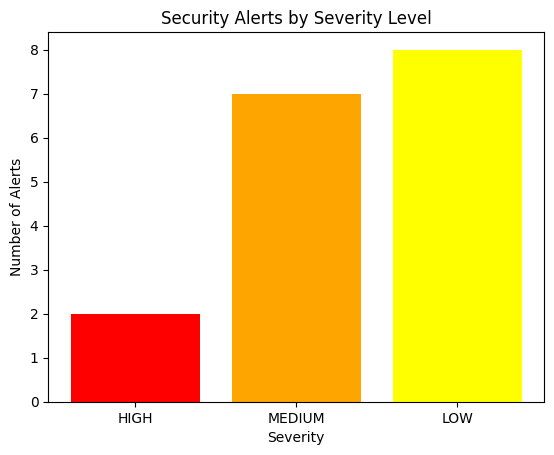

In [ ]:
import matplotlib.pyplot as plt

unusual_ips = unusual_hour_logs['ip'].unique()

severity_counts = {
    'HIGH': len(brute_force_ips),
    'MEDIUM': len(targeted_accounts) + len(scanning_ips),
    'LOW': len(unusual_ips) + len(suspicious_repeated_access)
}

plt.bar(severity_counts.keys(), severity_counts.values(), color=['red', 'orange', 'yellow'])
plt.title('Security Alerts by Severity Level')
plt.xlabel('Severity')
plt.ylabel('Number of Alerts')
plt.savefig('alerts_chart.png', dpi=150, bbox_inches='tight')
plt.show()